 Loading data from: housing_cleaned.csv
--- Step 1: Training Base Models ---
🌲 Training Random Forest (300 trees)...
--- Step 2: Creating Meta-Data for Judge ---
--- Step 3: Training the Judge ---

 Making Final Predictions...

 Model Performance:
   R2 Score:      0.9933
   Avg Error (MAE): ₹46,927
   MAPE:          0.0065
   Accuracy:      0.9935

--- First 10 Examples ---
Real Price      | Predicted       | Difference     
--------------------------------------------------
4,060,001         | 4,078,327         | 18,326
6,650,001         | 6,635,974         | 14,027
3,710,001         | 3,716,095         | 6,094
6,440,001         | 6,418,225         | 21,776
2,800,001         | 2,761,574         | 38,427
4,900,001         | 4,897,727         | 2,274
5,250,001         | 5,238,536         | 11,465
4,543,001         | 4,527,323         | 15,678
2,450,001         | 2,462,367         | 12,366
3,353,001         | 3,336,707         | 16,294


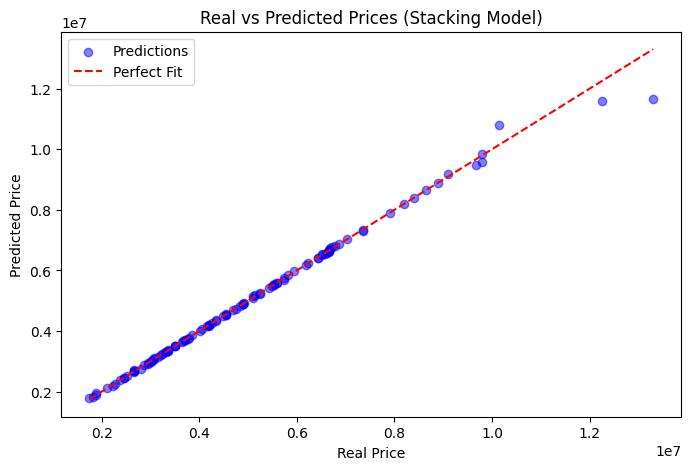


💾 Saving Model to 'house_model.pkl'...
✅ Success! Model saved. You can now move this file to your website backend.


In [ ]:
import numpy as np 
import pandas as pd 


class MyLinearRegression:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        """
        Trains the model using the Normal Equation:
        theta = (X^T * X)^-1 * X^T * y
        """
        m = X.shape[0] # number of rows
        # Add column of 1s for the bias term
        X_b = np.c_[np.ones((m, 1)), X]
        
        X_T = np.transpose(X_b)
        # Calculate weights
        self.weights = np.linalg.pinv(X_T.dot(X_b)).dot(X_T).dot(y)

    def predict(self, X):
        m = X.shape[0]
        # Add column of 1s to match training shape
        X_b = np.c_[np.ones((m, 1)), X]
        
        prediction = X_b.dot(self.weights)
        return prediction
class WeightedKNNRegressor:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        
        for x in X_test:
            # Calculate distances to all training points
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            k_indices = np.argsort(distances)[:self.k]
            k_prices = self.y_train[k_indices]
            k_distances = distances[k_indices]
            
            # Inverse weighting (closer neighbors matter more)
            weights = 1 / (k_distances + 1e-5)
            weighted_pred = np.sum(k_prices * weights) / np.sum(weights)
            predictions.append(weighted_pred)
            
        return np.array(predictions)

class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class MyDecisionTreeRegressor:
    def __init__(self, min_samples=2, max_depth=10):
        self.root = None
        self.min_samples = min_samples
        self.max_depth = max_depth

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y, curr_depth=0):
        num_samples, num_features = X.shape
        
        # Stopping conditions
        if num_samples < self.min_samples or curr_depth >= self.max_depth or len(np.unique(y)) == 1:
            return Node(value=np.mean(y))

        # Find best split
        best_split = self._get_best_split(X, y, num_samples, num_features)
        
        # If valid split found, grow tree
        if best_split["gain"] > 0:
            left_node = self._build_tree(best_split["X_left"], best_split["y_left"], curr_depth + 1)
            right_node = self._build_tree(best_split["X_right"], best_split["y_right"], curr_depth + 1)
            return Node(best_split["feature_index"], best_split["threshold"], left_node, right_node)
        
        return Node(value=np.mean(y))

    def _get_best_split(self, X, y, num_samples, num_features):
        best_split = {"gain": -1}
        max_var_red = -float("inf")
        current_var = np.var(y)
        
        for feature_index in range(num_features):
            feature_values = X[:, feature_index]
            unique_values = np.unique(feature_values)
            
            # Optimization: Check percentiles if too many values
            if len(unique_values) > 100:
                thresholds = np.percentile(feature_values, np.linspace(5, 95, 20))
            else:
                thresholds = unique_values

            for threshold in thresholds:
                left_mask = X[:, feature_index] <= threshold
                right_mask = ~left_mask
                
                if not np.any(left_mask) or not np.any(right_mask):
                    continue
                
                y_left, y_right = y[left_mask], y[right_mask]
                
                n, n_l, n_r = len(y), len(y_left), len(y_right)
                child_var = (n_l / n) * np.var(y_left) + (n_r / n) * np.var(y_right)
                gain = current_var - child_var
                
                if gain > max_var_red:
                    max_var_red = gain
                    best_split = {
                        "feature_index": feature_index, "threshold": threshold,
                        "X_left": X[left_mask], "y_left": y_left,
                        "X_right": X[right_mask], "y_right": y_right,
                        "gain": gain
                    }
        return best_split

    def predict(self, X):
        return np.array([self._make_prediction(x, self.root) for x in X])

    def _make_prediction(self, x, node):
        if node.value is not None: return node.value
        if x[node.feature_index] <= node.threshold:
            return self._make_prediction(x, node.left)
        else:
            return self._make_prediction(x, node.right)

class MyRandomForestRegressor:
    def __init__(self, n_trees=300, min_samples=2, max_depth=10):
        self.n_trees = n_trees
        self.min_samples = min_samples
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        print(f"Training Random Forest ({self.n_trees} trees)...")
        for i in range(self.n_trees):
            indices = np.random.choice(len(X), size=len(X), replace=True)
            X_sample = X[indices]
            y_sample = y[indices]
            
            tree = MyDecisionTreeRegressor(min_samples=self.min_samples, max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(tree_preds, axis=0)
class MyStackingRegressor:
    def __init__(self):
        
        self.linear = MyLinearRegression()
        self.knn = WeightedKNNRegressor(k=5)
        self.rf = MyRandomForestRegressor(n_trees=300, max_depth=10)
        self.judge = MyLinearRegression()

    def fit(self, X, y):
        self.linear.fit(X, y)
        self.knn.fit(X, y)
        self.rf.fit(X, y)
        
        p1 = self.linear.predict(X)
        p2 = self.knn.predict(X)
        p3 = self.rf.predict(X)
        
        
        stacked_predictions = np.column_stack((p1, p2, p3))
        
        self.judge.fit(stacked_predictions, y)

    def predict(self, X_test):
        
        p1 = self.linear.predict(X_test)
        p2 = self.knn.predict(X_test)
        p3 = self.rf.predict(X_test)
        
        
        stacked_predictions = np.column_stack((p1, p2, p3))
        
        # 3. Final Verdict
        return self.judge.predict(stacked_predictions)

